# Ejercicio 7 - Indicadores y tablero

El tablero se genera con **matplotlib** (`scripts/dashboard.py`), alimentado por las consultas `sql/07_*.sql` ejecutadas en DuckDB
sobre `trips_clean` (Parquet). Se guarda en `docs/dashboard.png`. Esta version ya incluye los tres anios (Ejercicio 8.4); el script
se adapta a los anios presentes.

## 7.1 Diez preguntas
1. Cuantos viajes hay por mes y como cambia entre anios? (I1)
2. Cuanto ingreso generan los viajes cada mes? (I2)
3. Cuanto cuesta y recorre en promedio un viaje, por taxi y anio? (I3)
4. En que dia y hora se concentra la demanda? (I4)
5. Que participacion tiene el taxi verde? (I5)
6. Como cambia el medio de pago? (I6)
7. Que propina dejan quienes pagan con tarjeta? (I7)
8. A que velocidad circulan los taxis durante el dia? (I8)
9. Que parte de los viajes paga el cargo de congestion (CBD)? (I9)
10. Que zonas concentran las recogidas? (I10)

## 7.2 y 7.6 Indicadores y justificacion
| Indicador | Metrica | Por que es relevante |
|-----------|---------|----------------------|
| I1 | viajes/mes por anio | volumen de demanda y estacionalidad: base de cualquier planificacion |
| I2 | ingresos/mes | traduce la demanda a dinero; separa efecto volumen de efecto precio |
| I3 | tarifa y distancia medias | precio del servicio y diferencia entre yellow y green |
| I4 | mapa de calor dia x hora | cuando hace falta oferta de vehiculos |
| I5 | % verde | salud del servicio de zonas exteriores frente al amarillo |
| I6 | mezcla de pago | cambios de captura/habitos; afecta la propina observable |
| I7 | propina % (tarjeta) | satisfaccion/ingreso del conductor; solo tarjeta por registro |
| I8 | velocidad por hora | proxy de congestion urbana |
| I9 | % con cargo CBD | efecto de la politica de peaje de congestion desde 2025 |
| I10 | top zonas | concentracion geografica de la demanda |

KPIs de cabecera: viajes validos, ingresos, tarifa media y % pago con tarjeta (`sql/07_kpi.sql`).

In [1]:
import sys; sys.path.insert(0, "../scripts")
import labutil as lu
from IPython.display import Image
con = lu.connect()

## 7.3 y 7.7 Consultas SQL (una por indicador)

In [2]:
for n in ["07_kpi", "07_i1_monthly_trips", "07_i2_revenue", "07_i3_fare_distance", "07_i4_heatmap",
          "07_i5_green_share", "07_i6_payment_mix", "07_i7_tips", "07_i8_speed", "07_i9_cbd_fee", "07_i10_top_zones"]:
    print((lu.SQL_DIR / f"{n}.sql").read_text())

-- KPI globales (tarjetas del tablero): viajes, ingresos, tarifa media y % pago con tarjeta.
-- Fuente: trips_clean.
SELECT count(*) AS viajes, sum(total_amount) AS ingresos, avg(fare_amount) AS tarifa_media,
       100.0 * avg(CASE WHEN payment_type = 1 THEN 1 ELSE 0 END) AS pct_tarjeta,
       min(data_year) AS anio_min, max(data_year) AS anio_max
FROM trips_clean;

-- I1 | P1: Cuantos viajes hay por mes y como cambia entre anios? (demanda)
SELECT data_year AS anio, data_month AS mes, count(*) AS viajes
FROM trips_clean GROUP BY ALL ORDER BY ALL;

-- I2 | P2: Cuantos ingresos (total_amount) generan los viajes cada mes? (negocio)
SELECT data_year AS anio, data_month AS mes, sum(total_amount) / 1e6 AS ingresos_musd
FROM trips_clean GROUP BY ALL ORDER BY ALL;

-- I3 | P3: Cuanto cuesta y cuanto recorre en promedio un viaje, por anio y taxi? (precio)
SELECT data_year AS anio, taxi, avg(fare_amount) AS tarifa_media, avg(trip_distance) AS dist_media,
       avg(fare_amount) / avg(trip_dist

## 7.4 y 7.5 Tablero

Tablero guardado en /Users/a87009/Documents/Año 4 Semestre 2/Data Science/Laboratorio 8 DuckDB/lab8-duckdb/docs/dashboard.png



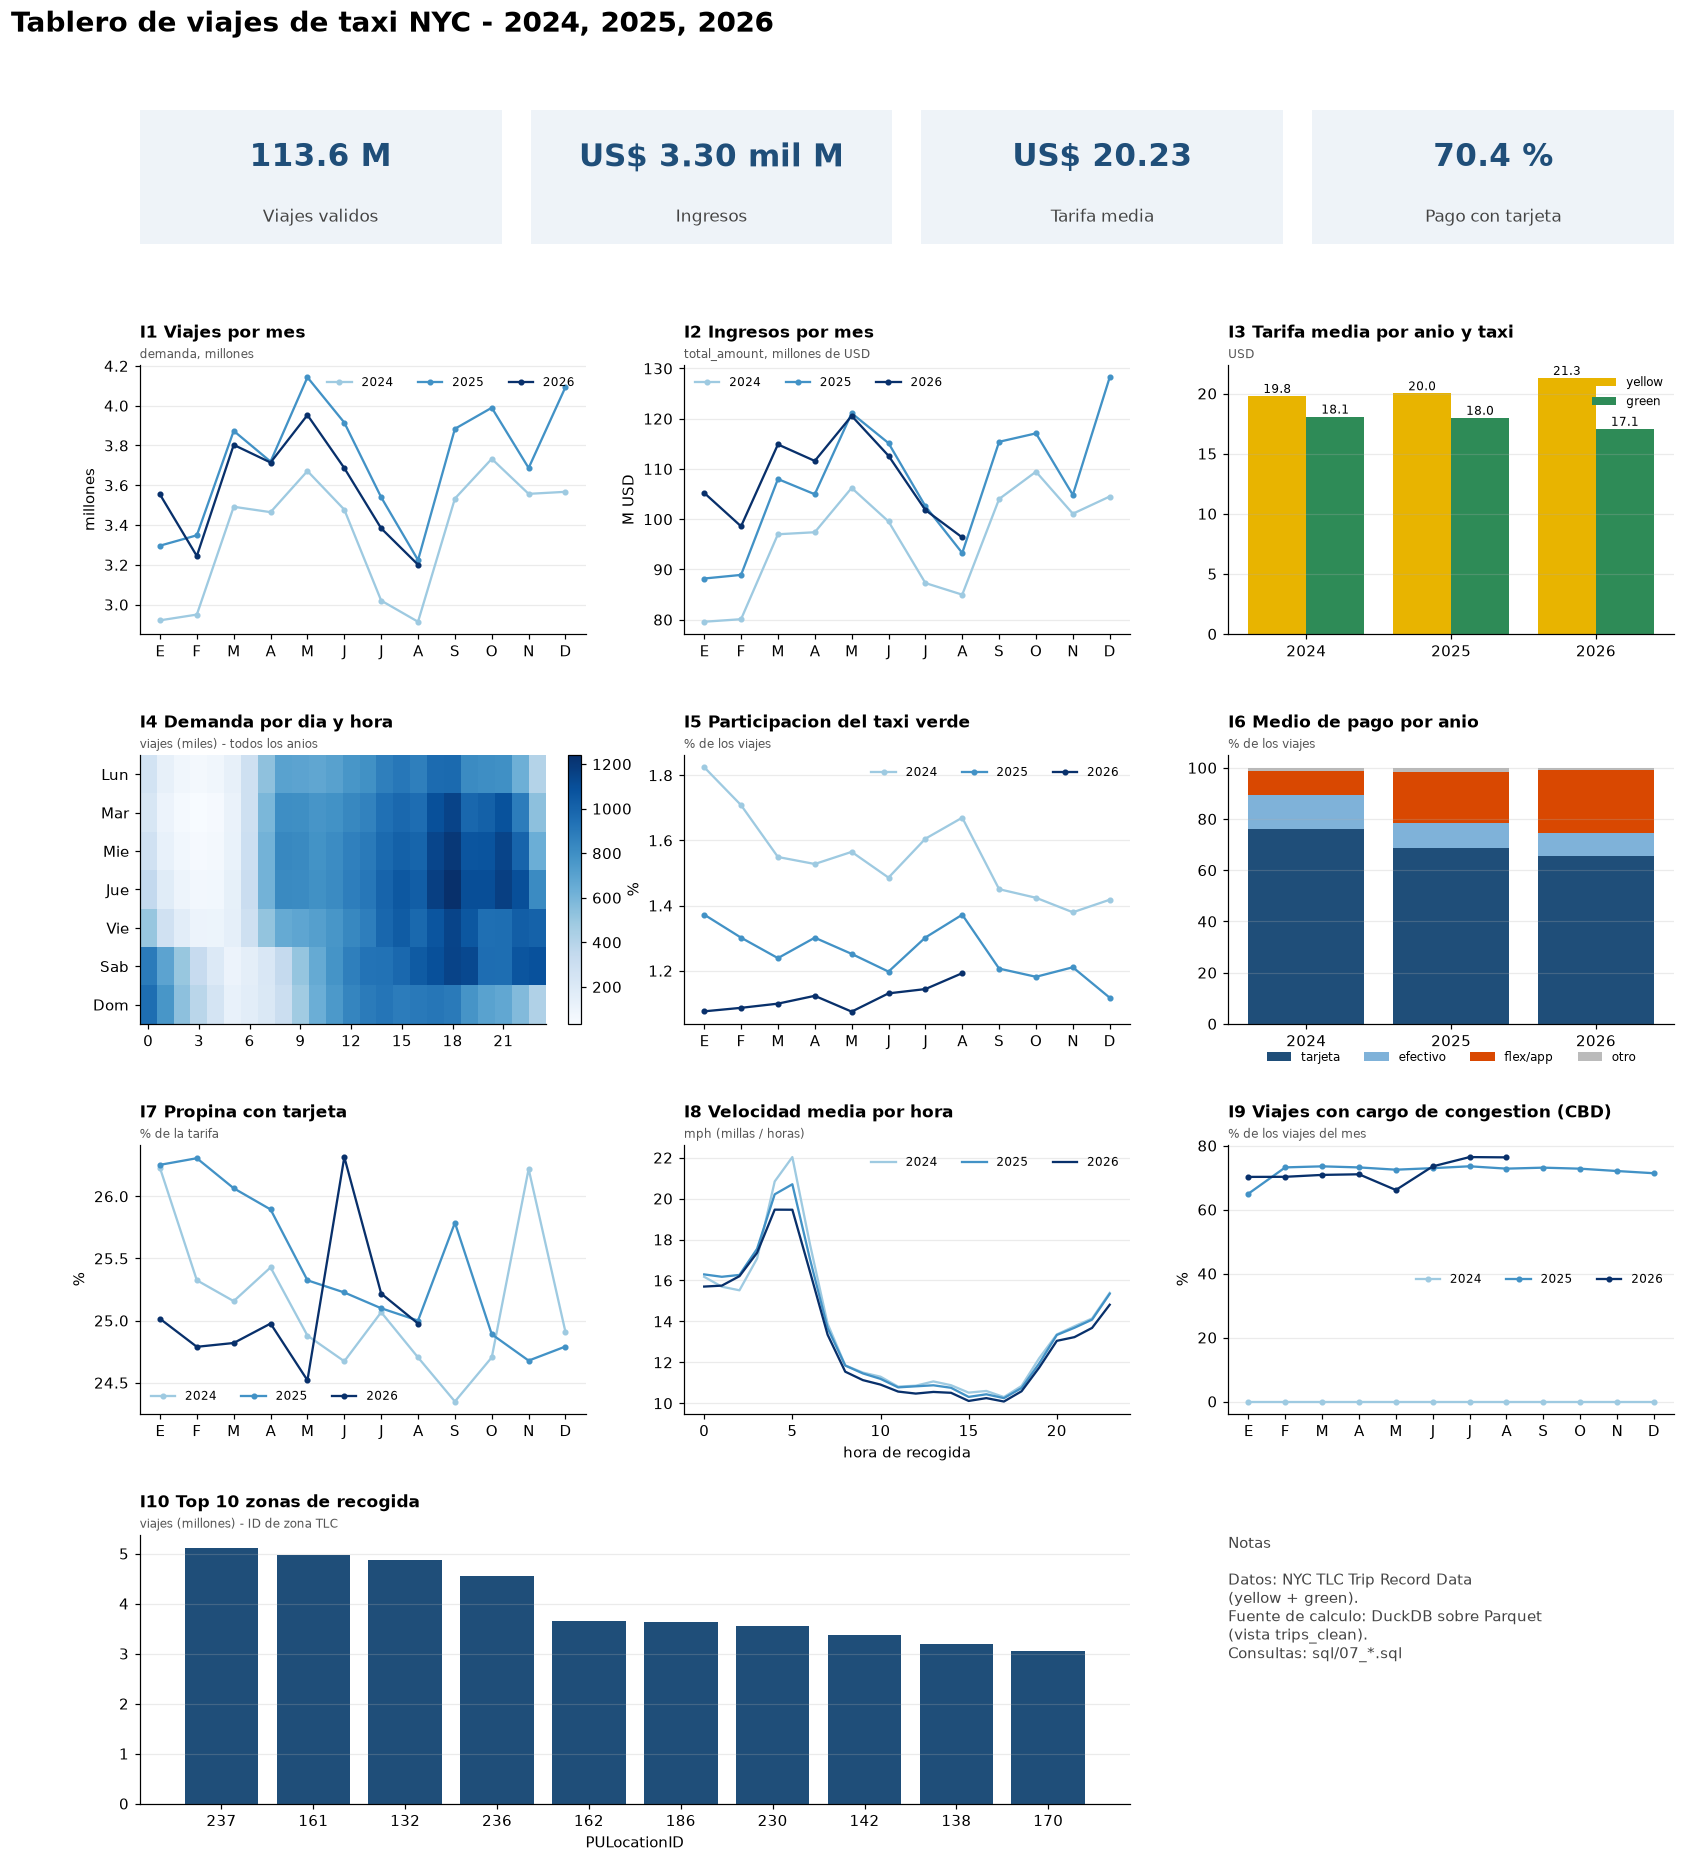

In [3]:
import subprocess
print(subprocess.run([sys.executable, "../scripts/dashboard.py"], capture_output=True, text=True).stdout)
Image("../docs/dashboard.png")

## 7.8 Interpretacion y hallazgos

- **Volumen (I1/I2):** el patron estacional es estable (febrero y agosto bajos, mayo y octubre-diciembre altos). 2025 supera a 2024 en todos los meses;
  2026 se mantiene por encima de 2024 pero **por debajo de 2025** de marzo en adelante. Los ingresos 2026 (ene-ago) igualan o superan a 2025 pese a menos viajes: sube el precio.
- **Precio (I3):** la tarifa media yellow sube de 19.8 (2024) a 21.3 USD (2026) mientras la verde baja de 18.1 a 17.1; la brecha se amplia.
- **Demanda semanal (I4):** maximos martes-jueves a las 17-19 h; sabado noche y madrugada de sabado/domingo tambien son fuertes (vida nocturna).
- **Participacion verde (I5):** cae continuamente de ~1.6% (2024) a ~1.1% (2026) de los viajes.
- **Pagos (I6):** la tarjeta baja de 76% a 65% mientras `flex/app` (payment_type 0) sube de 9% a 25% (ene-ago: 8.8, 19.4 y 24.7%).
- **Propina (I7):** estable en ~25% de la tarifa con tarjeta en los tres anios; la variabilidad mensual es ruido.
- **Velocidad (I8):** la ciudad se mueve a ~10-11 mph de dia y ~20 mph a las 4-5 h; en 2026 los taxis son ~0.6 mph mas lentos que en 2025 (ene-ago).
- **CBD (I9):** el cargo no existe en 2024 y lo paga ~72% de los viajes desde enero 2025 (0.75 USD): la poca variacion indica que casi todo el servicio opera en la zona cobrada.
- **Zonas (I10):** las zonas 237, 161, 132 y 236 (Manhattan y aeropuerto JFK) encabezan con ~5 M de viajes cada una.